In [46]:
import numpy as np
import nibabel as nib
from nilearn import surface
import matplotlib.pyplot as plt




def generate_flatmap(
    voxel_data, 
    subject_id="subj01", 
    surf_type="full.flat.patch.3d", 
    view_number=1, 
    hemi="both",
    surf_suffix="orig",
    colormap="jet", 
    clim=None
):
    """
    Generate a 2D flatmap or cortical surface projection from voxel data.
    
    Parameters:
        voxel_data (numpy array): 1D array of voxel data (e.g., concatenated left and right hemisphere).
        subject_id (str): FreeSurfer subject ID (default: "fsaverage").
        surf_type (str): Type of cortical surface (e.g., 'inflated', 'sphere', 'flat', etc.).
        view_number (int): Predefined surface view configuration (not directly used in this basic example).
        hemi (str): Hemisphere ('lh', 'rh', or 'both').
        surf_suffix (str): Surface suffix to use ('orig', 'DENSETRUNCpt', etc.).
        colormap (str): Colormap for visualization (default: "jet").
        clim (list or tuple): Color range [min, max] (default: data range).
    
    Returns:
        2D flatmap visualization of voxel data.
    """



    # Load the surface geometry (e.g., FreeSurfer files)
    subjects_dir = f"data/surf/{subject_id}/surf"  # Set this to your FreeSurfer SUBJECTS_DIR
    hemis = ["lh", "rh"] if hemi == "both" else [hemi]
    
    # Initialize arrays to hold surface geometry and data
    vertices = []
    faces = []
    surface_data = []

    for h in hemis:
        surf_file = f"{subjects_dir}/{h}.{surf_type}"
        curv_file = f"{subjects_dir}/{h}.curv"

        print(f"{surf_file=}")
        
        # Load surface geometry (vertices and faces)
        coords, triangles = nib.freesurfer.read_geometry(surf_file)
        vertices.append(coords)
        faces.append(triangles)
        
        # Optionally, load curvature to provide a background contrast
        curv = nib.freesurfer.read_morph_data(curv_file)
        surface_data.append(curv)
    
    # Concatenate hemispheres
    vertices = np.vstack(vertices)
    faces = np.vstack(faces)
    surface_data = np.concatenate(surface_data)
    
    # Ensure voxel_data matches surface data size
    if voxel_data is None:
        voxel_data = np.random.randn(len(surface_data))  # Generate random data
    elif len(voxel_data) != len(surface_data):
        raise ValueError("Voxel data size must match the number of surface vertices.")
    
    # Map voxel data to surface
    if clim is None:
        clim = (np.percentile(voxel_data, 1), np.percentile(voxel_data, 99))
    
    
    facecolors = np.mean(voxel_data[faces], axis=1)

    # Visualize the surface as a flatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    plot = ax.tripcolor(
        vertices[:, 0], 
        vertices[:, 1], 
        faces, 
        facecolors=facecolors, 
        cmap=colormap, 
        shading="flat"
    )
    plt.colorbar(plot, ax=ax, label="Voxel Data")
    plot.set_clim(*clim)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.title("Flatmap Visualization")
    plt.show()
    
    # # Visualize the surface as a flatmap
    # fig, ax = plt.subplots(figsize=(10, 8))
    # plot = ax.tripcolor(vertices[:, 0], vertices[:, 1], faces, facecolors=voxel_data, cmap=colormap, shading="flat")
    # plt.colorbar(plot, ax=ax, label="Voxel Data")
    # plot.set_clim(*clim)
    # ax.set_aspect("equal")
    # ax.axis("off")
    # plt.title(f"Flatmap: {subject_id} ({surf_type})")
    # plt.show()

In [47]:
def plot_curvature(subject_id="subj01", surf_type="flat", hemi="both"):
    """
    Plot the flattened brain surface with curvature data for shading.
    
    Parameters:
        subject_id (str): FreeSurfer subject ID (default: "fsaverage").
        surf_type (str): Type of surface (default: "flat").
        hemi (str): Hemisphere ("lh", "rh", or "both").
    """
    subjects_dir = f"data/surf/{subject_id}/surf"  # Set this to your FreeSurfer SUBJECTS_DIR
    hemis = ["lh", "rh"] if hemi == "both" else [hemi]
    
    # Initialize arrays to hold surface geometry and curvature
    vertices = []
    faces = []
    curvature = []

    for h in hemis:
        # Paths to surface geometry and curvature files
        surf_file = f"{subjects_dir}/{h}.{surf_type}"
        curv_file = f"{subjects_dir}/{h}.curv"
        
        # Load surface geometry
        coords, triangles = nib.freesurfer.read_geometry(surf_file)
        vertices.append(coords)
        faces.append(triangles)
        
        # Load curvature data
        curv = nib.freesurfer.read_morph_data(curv_file)
        curvature.append(curv)
    
    # Concatenate hemispheres
    vertices = np.vstack(vertices)
    faces = np.vstack(faces)
    curvature = np.concatenate(curvature)
    
    # Calculate facecolors (average curvature for each triangle)
    facecolors = np.mean(curvature[faces], axis=1)

    # Plot the surface with curvature shading
    fig, ax = plt.subplots(figsize=(10, 8))
    plot = ax.tripcolor(
        vertices[:, 0], 
        vertices[:, 1], 
        faces, 
        facecolors=facecolors, 
        cmap="gray", 
        shading="flat"
    )
    plt.colorbar(plot, ax=ax, label="Curvature")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.title(f"Curvature on {surf_type} surface for {subject_id}")
    plt.show()

surf_file='data/surf/subj01/surf/lh.orig'
surf_file='data/surf/subj01/surf/rh.orig'


KeyboardInterrupt: 

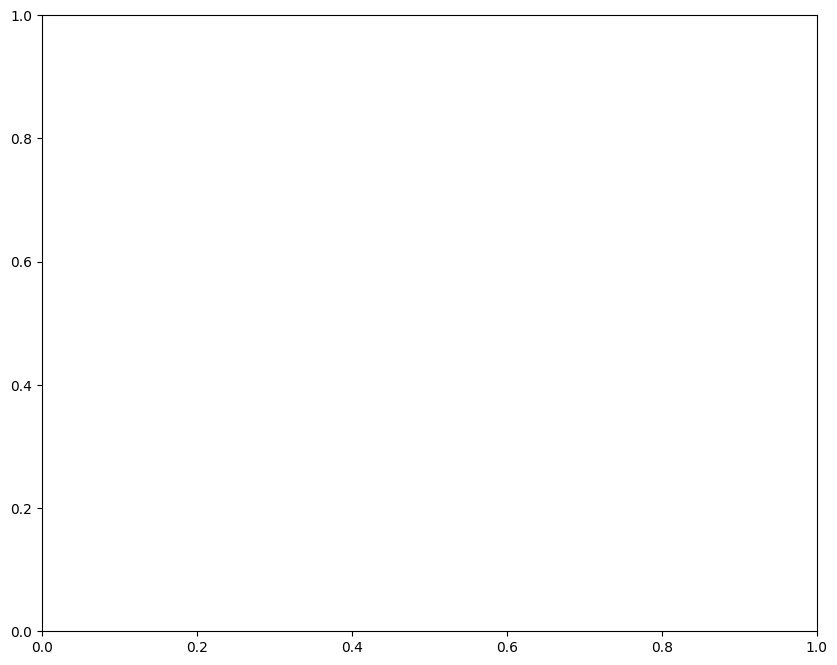

In [48]:
generate_flatmap(None, surf_type="orig")

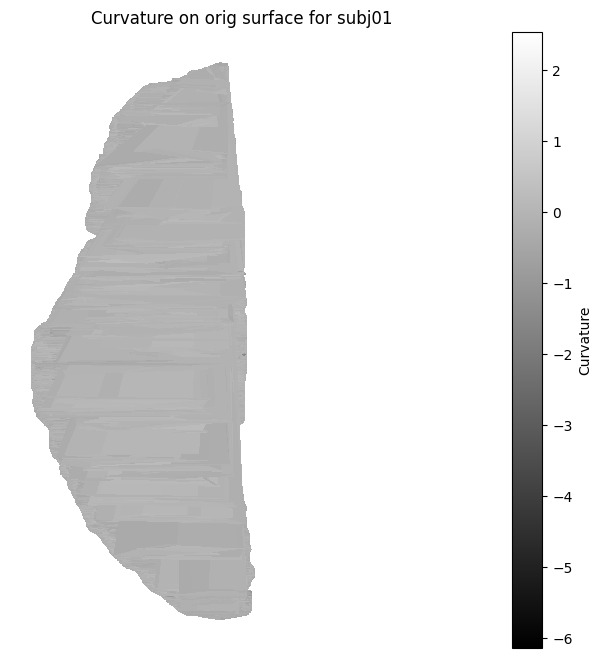

In [28]:
plot_curvature(surf_type="orig")

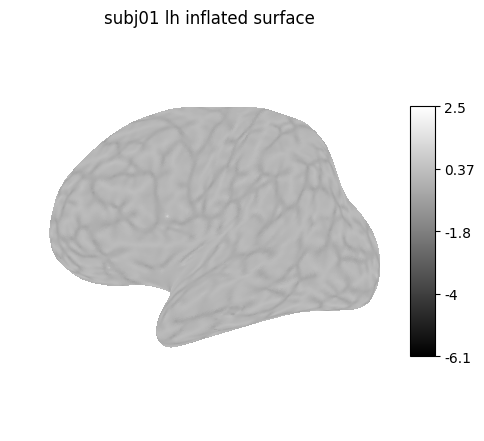

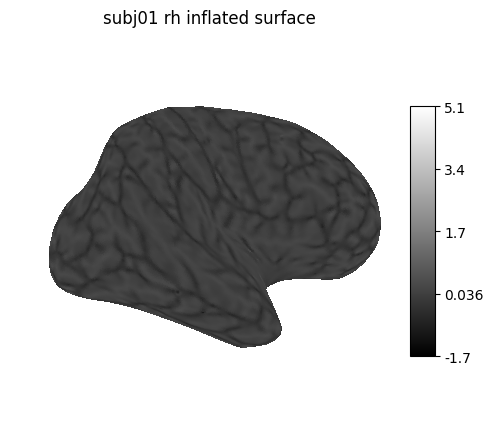

In [31]:
from nilearn import surface, plotting
import nibabel as nib
import matplotlib.pyplot as plt

def plot_curvature_nilearn(subject_id="subj01", hemi="both", surf_type="inflated"):
    """
    Visualize a flattened brain surface with curvature using Nilearn.
    
    Parameters:
        subject_id (str): FreeSurfer subject ID (default: "fsaverage").
        hemi (str): Hemisphere to plot ("lh", "rh", or "both").
        surf_type (str): Surface type to use for visualization (default: "inflated").
    """
    subjects_dir = f"data/surf/{subject_id}/surf"  # Set this to your FreeSurfer SUBJECTS_DIR
    hemis = ["lh", "rh"] if hemi == "both" else [hemi]

    for h in hemis:
        # Paths to surface and curvature files
        surf_file = f"{subjects_dir}/{h}.{surf_type}"
        curv_file = f"{subjects_dir}/{h}.curv"
        
        # Load curvature data
        curvature = nib.freesurfer.read_morph_data(curv_file)
        
        # Use Nilearn to plot the surface with curvature
        plotting.plot_surf(
            surf_file,
            surf_map=curvature,
            hemi="left" if h == "lh" else "right",
            view="lateral",
            cmap="gray",
            colorbar=True,
            title=f"{subject_id} {h} {surf_type} surface",
        )
    plt.show()


# Example Usage
plot_curvature_nilearn(subject_id="subj01", hemi="both", surf_type="inflated")

In [ ]:
plot_curvature_nilearn(subject_id="subj01", hemi="both", surf_type="full.flat.patch.3d")

ValueError: The input type is not recognized. 'data/surf/subj01/surf/lh.full.flat.patch.3d' was given while valid inputs are one of the following file formats: .gii, .gii.gz, Freesurfer specific files such as '.orig', '.pial', '.sphere', '.white', '.infla', two Numpy arrays organized in a list, tuple or a namedtuple with the fields "coordinates" and "faces".

In [ ]:
import numpy as np

def load_flat_patch_3d_binary(file_path):
    """
    Parse a binary .3d file to extract vertices and faces.

    Parameters:
        file_path (str): Path to the binary .3d file.

    Returns:
        vertices (numpy array): Array of 2D vertex coordinates (n_vertices x 2).
        faces (numpy array): Array of triangular faces (n_faces x 3).
    """
    with open(file_path, 'rb') as f:
        # Read the number of vertices and faces
        n_vertices = int(np.fromfile(f, dtype=np.int32, count=1))  # Number of vertices
        n_faces = int(np.fromfile(f, dtype=np.int32, count=1))      # Number of faces

        # Read vertex coordinates (assume 2D vertices)
        vertices = np.fromfile(f, dtype=np.float32, count=n_vertices * 2)
        vertices = vertices.reshape(n_vertices, 2)

        # Read faces (assume 3 indices per face)
        faces = np.fromfile(f, dtype=np.int32, count=n_faces * 3)
        faces = faces.reshape(n_faces, 3)

    return vertices, faces

# Example Usage
vertices, faces = load_flat_patch_3d_binary("data/surf/subj01/surf/lh.full.flat.patch.3d")


/tmp/ipykernel_41987/960243728.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_vertices = int(np.fromfile(f, dtype=np.int32, count=1))  # Number of vertices
/tmp/ipykernel_41987/960243728.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_faces = int(np.fromfile(f, dtype=np.int32, count=1))      # Number of faces


MemoryError: Unable to allocate 18.4 GiB for an array with shape (4945086720,) and data type int32

[[[7.473597 ]]

 [[6.9733663]]

 [[6.1700726]]

 ...

 [[6.2630105]]

 [[8.465707 ]]

 [[6.6486983]]]


/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


[nan nan nan ... nan nan nan]


/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:528: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(data) if vmin is None else vmin
/home/max/python_projects/master_thesis/venv/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:529: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(data) if vmax is None else vmax


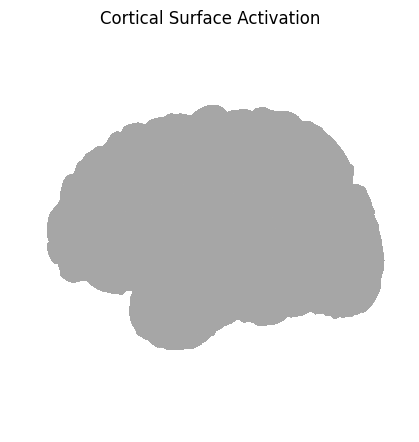

In [49]:
import nibabel as nib
from nilearn import surface, plotting

# Load volumetric data
volume_img = nib.load('data/surf/subj01/lh.t_test_signed_0_0_label_across_clip_7.mgz')

print(np.asanyarray(volume_img.dataobj))

# Load FreeSurfer surface file
fsaverage_pial = 'data/surf/subj01/surf/lh.pial'

# Project the volumetric data to the cortical surface
surf_data = surface.vol_to_surf(volume_img, fsaverage_pial)
print(surf_data)
# Plot the surface with Nilearn
plotting.plot_surf(
    surf_mesh=fsaverage_pial,
    surf_map=surf_data,
    hemi="left",
    title="Cortical Surface Activation"
)

# Save the flattened surface data
import numpy as np
np.save('flattened_surface_data.npy', surf_data)